<p align="center">
  <span style="color:Navy; font-size:200%; font-weight:bold; vertical-align:middle;">
    Temas Selectos: Python para Ciencias de la Tierra
  </span>
  <img src="attachment:LOGO_ENCIT.png" alt="ENCiT" width="190" style="vertical-align:middle; margin-left:20px;"/>
</p>
<p align="center" style="line-height:1.2;">
  <span style="color:RoyalBlue; font-size:160%;">Tema 4: Métodos numéricos </span><br/>
  <span style="color:DodgerBlue; font-size:140%;">Notebook: Interpolación e integración numérica </span><br/>
  <span style="font-size:100%;color:forestgreen"> Escuela Nacional de Ciencias de la Tierra  |  Semestre 2026-II</span>
</p>

---

# <font color="darkblue"> Introducción </font>

En este notebook exploraremos dos familias de herramientas numéricas que aparecen constantemente en el análisis de datos geofísicos y ambientales: la **interpolación** y la **integración numérica**.



La **interpolación** permite estimar valores en posiciones donde no tenemos observaciones directas, ya sea en el tiempo o en el espacio. En ciencias de la Tierra esto ocurre constantemente: los instrumentos miden en puntos discretos, las estaciones meteorológicas se distribuyen de forma irregular y los modelos climáticos producen datos en mallas que no coinciden con las de otros productos.

La **integración numérica** permite calcular áreas bajo curvas cuando no conocemos la función analítica, sino únicamente sus valores en puntos discretos. Esto es útil para calcular la energía acumulada bajo un perfil de temperatura, el flujo total a través de una sección, o la cantidad de CO₂ que ha excedido un nivel de referencia a lo largo del tiempo.

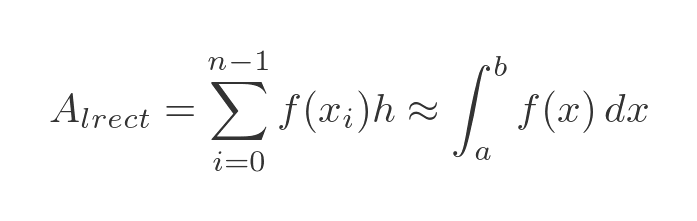

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.interpolate import interp1d, CubicSpline, griddata
from scipy.integrate import trapezoid, simpson
from statsmodels.datasets import co2

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## <font color="darkgreen"> 1. Interpolación en una dimensión</font>

Cuando registramos una variable a lo largo del tiempo, los datos siempre son **discretos**: tenemos mediciones en ciertos instantes, pero no en todos. La interpolación es el proceso de estimar el valor de una función en un punto intermedio entre observaciones conocidas.

En esta sección trabajaremos con la serie histórica de **CO₂ atmosférico** medida en el Observatorio de Mauna Loa, Hawái. Esta serie semanal (1958–2001) disponible en `statsmodels` contiene algunos valores faltantes que son un ejemplo natural del problema de interpolación en datos reales.

### <font color="deeppink"> 1.1 Interpolación, extrapolación y remuestreo de datos discretos</font>

Antes de entrar a los métodos conviene distinguir tres operaciones relacionadas:

- **Interpolación**: estimar valores *dentro* del rango de los datos conocidos, entre dos puntos de observación.
- **Extrapolación**: estimar valores *fuera* del rango; más arriesgada porque asume que el comportamiento observado continúa más allá de lo medido.
- **Remuestreo**: cambiar la resolución temporal o espacial de un conjunto de datos. El remuestreo hacia alta resolución requiere interpolación.

Comenzaremos explorando la serie de CO₂ antes de cualquier procesamiento.

In [115]:
# Cargar la serie de CO₂ de Mauna Loa (datos semanales, 1958–2001)
df_co2 = co2.load_pandas().data
df_co2.index = pd.to_datetime(df_co2.index)

# Remuestrear a promedio mensual
df_co2_monthly = df_co2.resample('ME').mean()

print(f"Período   : {df_co2_monthly.index[0].date()} → {df_co2_monthly.index[-1].date()}")
print(f"Meses     : {len(df_co2_monthly)}")
print(f"NaN totales: {df_co2_monthly['co2'].isna().sum()}")
df_co2_monthly.head(6)

Período   : 1958-03-31 → 2001-12-31
Meses     : 526
NaN totales: 5


,co2
1958-03-31,316.100000
1958-04-30,317.200000
1958-05-31,317.433333
1958-06-30,NaN
1958-07-31,315.625000
1958-08-31,314.950000


### <font color="ForestGreen"> Análisis exploratorio de la serie de CO₂ </font>

La serie de Mauna Loa es uno de los registros instrumentales más importantes en el estudio del cambio climático. Antes de interpolar conviene entender su estructura: la tendencia de largo plazo, el ciclo estacional, y la ubicación de los datos faltantes.

In [116]:
# Estadísticas descriptivas básicas
df_co2_monthly['co2'].describe().round(2)

count    521.00
mean     339.82
std       17.07
min      313.40
25%      324.12
50%      337.95
75%      354.68
max      373.80
Name: co2, dtype: float64

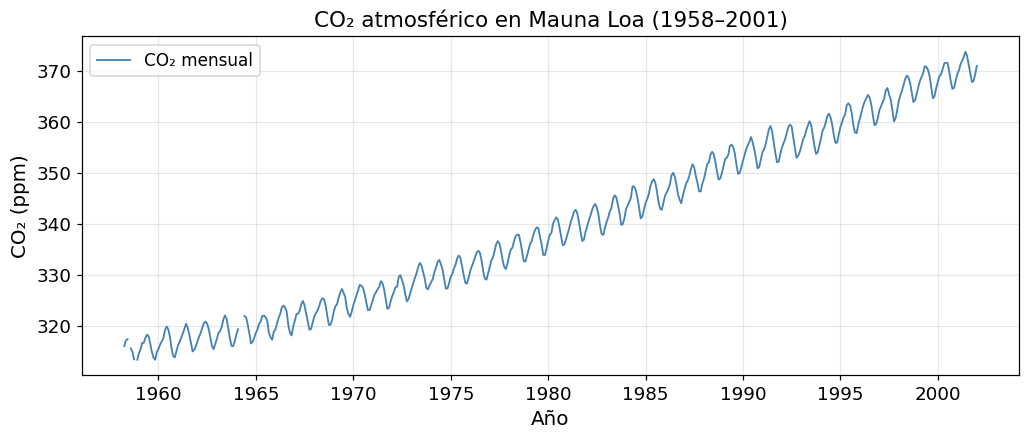

In [117]:
# Serie completa: tendencia de largo plazo
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(df_co2_monthly.index, df_co2_monthly['co2'],
        color='steelblue', linewidth=1.2, label='CO₂ mensual')

ax.set_title('CO₂ atmosférico en Mauna Loa (1958–2001)', fontsize=14)
ax.set_xlabel('Año', fontsize=13)
ax.set_ylabel('CO₂ (ppm)', fontsize=13)
ax.tick_params(labelsize=12)
ax.legend(fontsize=11)

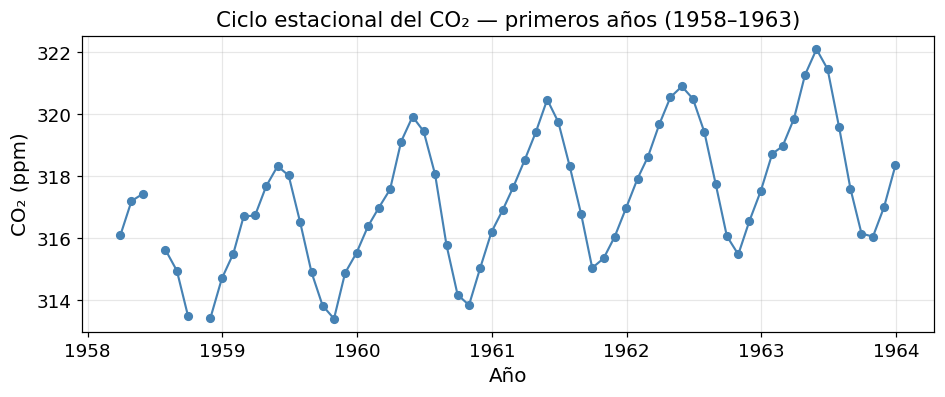

In [118]:
# Ciclo estacional: zoom a los primeros 6 años
mascara_primeros = (df_co2_monthly.index.year >= 1958) & (df_co2_monthly.index.year <= 1963)

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(df_co2_monthly.index[mascara_primeros],
        df_co2_monthly['co2'][mascara_primeros],
        'o-', ms=5, color='steelblue', linewidth=1.4)

ax.set_title('Ciclo estacional del CO₂ — primeros años (1958–1963)', fontsize=14)
ax.set_xlabel('Año', fontsize=13)
ax.set_ylabel('CO₂ (ppm)', fontsize=13)
ax.tick_params(labelsize=12)

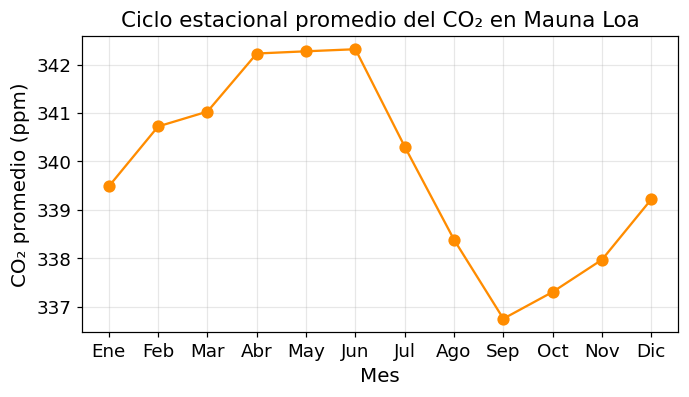

In [119]:
# Ciclo anual promedio (promedio de cada mes sobre todos los años)
ciclo_anual = df_co2_monthly.groupby(df_co2_monthly.index.month)['co2'].mean()
meses_etiq  = ['Ene','Feb','Mar','Abr','May','Jun',
               'Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(7, 3.5))

ax.plot(ciclo_anual.index, ciclo_anual.values,
        'o-', color='darkorange', linewidth=1.5, ms=7)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_etiq, fontsize=12)
ax.set_title('Ciclo estacional promedio del CO₂ en Mauna Loa', fontsize=14)
ax.set_xlabel('Mes', fontsize=13)
ax.set_ylabel('CO₂ promedio (ppm)', fontsize=13)
ax.tick_params(axis='y', labelsize=12)

El ciclo anual refleja la respiración de la biosfera terrestre: el CO₂ aumenta en invierno boreal (menor actividad fotosintética) y disminuye en verano (mayor fotosíntesis en el hemisferio norte, donde está la mayor parte de la masa continental). La amplitud del ciclo es de aproximadamente 6 ppm.

Ahora veamos dónde están los valores faltantes.

In [120]:
# Ubicar los meses con NaN en la serie
meses_nan = df_co2_monthly[df_co2_monthly['co2'].isna()].index
print(f"Meses con NaN: {len(meses_nan)}")
print("Fechas:", [str(d.date()) for d in meses_nan])

Meses con NaN: 5
Fechas: ['1958-06-30', '1958-10-31', '1964-02-29', '1964-03-31', '1964-04-30']


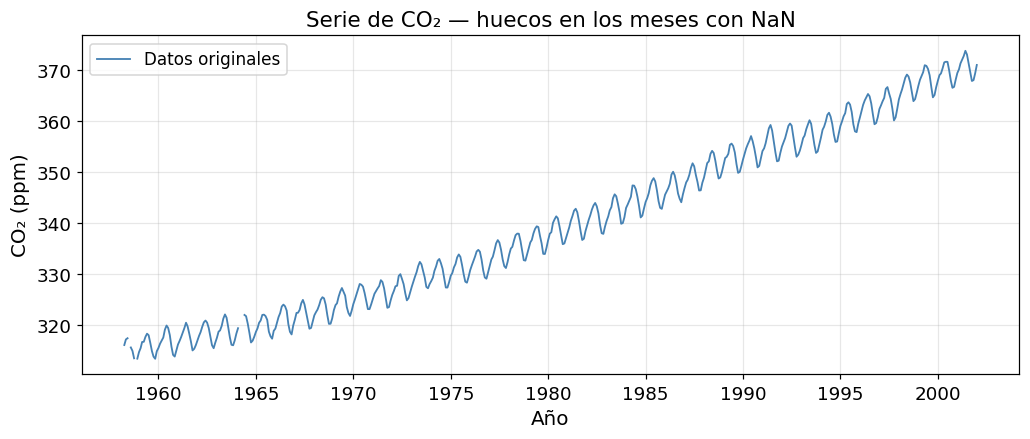

In [121]:
# Visualizar la serie con los huecos naturales del NaN
# (pandas no dibuja línea donde hay NaN, los huecos son visibles)
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(df_co2_monthly.index, df_co2_monthly['co2'],
        color='steelblue', linewidth=1.2, label='Datos originales')

ax.set_title('Serie de CO₂ — huecos en los meses con NaN', fontsize=14)
ax.set_xlabel('Año', fontsize=13)
ax.set_ylabel('CO₂ (ppm)', fontsize=13)
ax.tick_params(labelsize=12)
ax.legend(fontsize=11)

In [122]:
# Rellenar los NaN con interpolación lineal de pandas
df_co2_filled = df_co2_monthly.copy()
df_co2_filled['co2'] = df_co2_filled['co2'].interpolate(method='linear')

print(f"NaN restantes tras interpolación: {df_co2_filled['co2'].isna().sum()}")

NaN restantes tras interpolación: 0


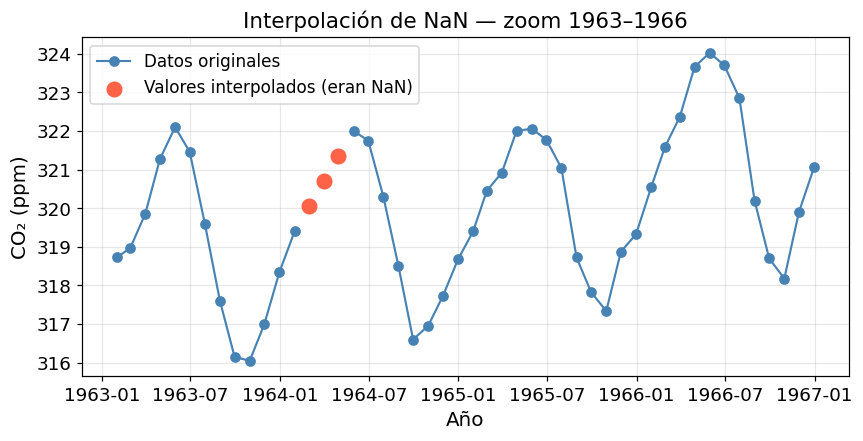

In [123]:
# Comparar datos originales con valores interpolados en la zona con NaN (1964)
mascara_64 = (df_co2_monthly.index.year >= 1963) & (df_co2_monthly.index.year <= 1966)
nan_en_zoom = df_co2_monthly['co2'][mascara_64].isna()

fig, ax = plt.subplots(figsize=(9, 4))

# Serie completa (original — tendrá huecos donde había NaN)
ax.plot(df_co2_monthly.index[mascara_64],
        df_co2_monthly['co2'][mascara_64],
        'o-', ms=6, color='steelblue', linewidth=1.4, label='Datos originales')

# Marcar exactamente los puntos que fueron NaN con su valor interpolado
ax.scatter(df_co2_filled.index[mascara_64][nan_en_zoom],
           df_co2_filled['co2'][mascara_64][nan_en_zoom],
           color='tomato', s=90, zorder=5, label='Valores interpolados (eran NaN)')

ax.set_title('Interpolación de NaN — zoom 1963–1966', fontsize=14)
ax.set_xlabel('Año', fontsize=13)
ax.set_ylabel('CO₂ (ppm)', fontsize=13)
ax.tick_params(labelsize=12)
ax.legend(fontsize=11)

<div class="alert alert-block alert-info">
<b>Interpolación vs extrapolación:</b> En el ejemplo anterior los valores faltantes están <em>rodeados</em> de observaciones, por lo que el relleno es una interpolación genuina. Si los NaN estuvieran al principio o al final de la serie, tendríamos que extrapolar, lo cual es inherentemente más incierto. <code>pandas.interpolate</code> no extrapola por defecto; los NaN en los extremos quedan sin rellenar.
</div>

### <font color="deeppink"> 1.2 Interpolación lineal y polinomial</font>

La herramienta central para interpolación 1D en SciPy es `interp1d`, que permite elegir el método con el argumento `kind`:

- `'linear'`: une los puntos conocidos con segmentos de recta. Simple y robusto, pero produce derivadas discontinuas en los nodos (la curva "se dobla" en cada punto observado).
- `'quadratic'` y `'cubic'`: ajustan polinomios de grado 2 o 3 a grupos de puntos vecinos, produciendo una curva más suave.

Un problema conocido de la **interpolación polinomial de alto grado** con polinomios globales es el *fenómeno de Runge*: cerca de los extremos, las oscilaciones pueden crecer mucho aunque los datos sean suaves. Por eso en la siguiente sección se usan **splines**.

Para mostrar la diferencia, simularemos una red de observación escasa tomando sólo 1 punto cada 18 meses de la serie de CO₂ e intentaremos reconstruir la serie completa.

In [124]:
# Construir versión "escasa": 1 observación cada 18 meses
co2_vals = df_co2_filled['co2'].values
tiempo   = np.arange(len(co2_vals), dtype=float)   # índice numérico (meses)

paso = 18
idx_escaso = np.arange(0, len(tiempo), paso)
t_escaso   = tiempo[idx_escaso]
y_escaso   = co2_vals[idx_escaso]

print(f"Puntos originales : {len(tiempo)}")
print(f"Puntos escasos    : {len(t_escaso)}  (1 de cada {paso})")

Puntos originales : 526
Puntos escasos    : 30  (1 de cada 18)


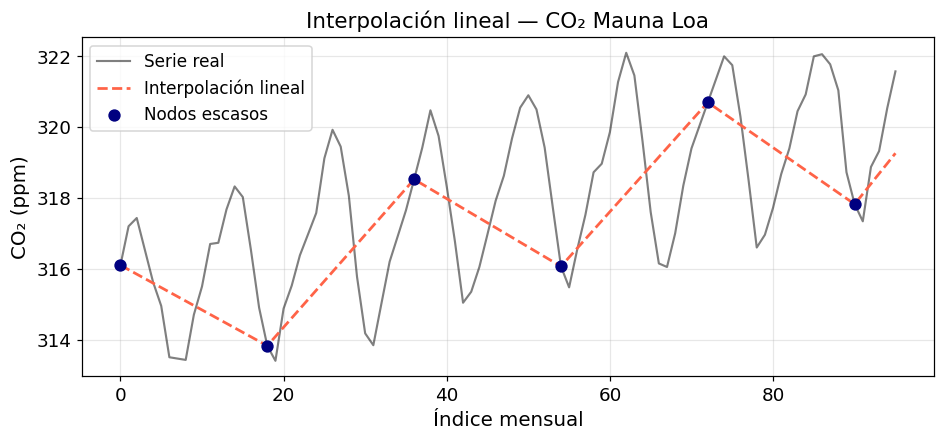

In [125]:
# Interpolación lineal con scipy.interpolate.interp1d
f_lineal = interp1d(t_escaso, y_escaso, kind='linear', fill_value='extrapolate')
y_lineal = f_lineal(tiempo)

# Tramo para visualización: primeros ~8 años (96 meses)
seg = slice(0, 96)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(tiempo[seg], co2_vals[seg],
        'k-', linewidth=1.4, alpha=0.5, label='Serie real')
ax.plot(tiempo[seg], y_lineal[seg],
        '--', color='tomato', linewidth=1.8, label='Interpolación lineal')
ax.scatter(t_escaso[t_escaso <= tiempo[seg.stop - 1]],
           y_escaso[t_escaso <= tiempo[seg.stop - 1]],
           s=50, color='navy', zorder=5, label='Nodos dispersos')

ax.set_title('Interpolación lineal — CO₂ Mauna Loa', fontsize=14)
ax.set_xlabel('Índice mensual', fontsize=13)
ax.set_ylabel('CO₂ (ppm)', fontsize=13)
ax.tick_params(labelsize=12)
ax.legend(fontsize=11)

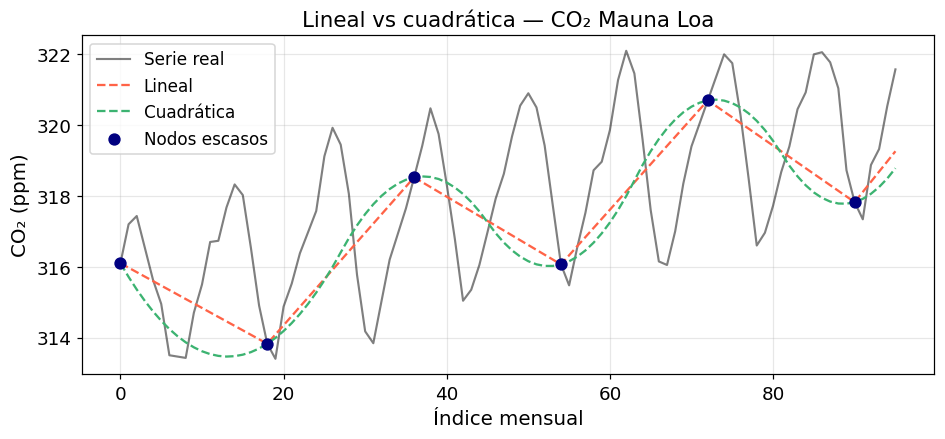

In [126]:
# Interpolación cuadrática con interp1d
f_cuad = interp1d(t_escaso, y_escaso, kind='quadratic', fill_value='extrapolate')
y_cuad = f_cuad(tiempo)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(tiempo[seg], co2_vals[seg],
        'k-', linewidth=1.4, alpha=0.5, label='Serie real')
ax.plot(tiempo[seg], y_lineal[seg],
        '--', color='tomato', linewidth=1.5, label='Lineal')
ax.plot(tiempo[seg], y_cuad[seg],
        '--', color='mediumseagreen', linewidth=1.5, label='Cuadrática')
ax.scatter(t_escaso[t_escaso <= tiempo[seg.stop - 1]],
           y_escaso[t_escaso <= tiempo[seg.stop - 1]],
           s=50, color='navy', zorder=5, label='Nodos dispersos')

ax.set_title('Lineal vs cuadrática — CO₂ Mauna Loa', fontsize=14)
ax.set_xlabel('Índice mensual', fontsize=13)
ax.set_ylabel('CO₂ (ppm)', fontsize=13)
ax.tick_params(labelsize=12)
ax.legend(fontsize=11)

### <font color="deeppink"> 1.3 Splines e interpolación cúbica</font>

Un **spline** es una función construida por tramos: cada tramo es un polinomio de bajo grado (generalmente cúbico) y las uniones entre tramos satisfacen condiciones de suavidad —continuidad en la función, en su primera derivada y en su segunda derivada. El resultado es una curva globalmente suave sin las oscilaciones del polinomio global.

La clase `CubicSpline` de SciPy implementa el **spline cúbico natural**, que impone además que la segunda derivada sea cero en los extremos. Su uso es muy sencillo:

```python
from scipy.interpolate import CubicSpline

cs = CubicSpline(x, y)     # construir el spline con los nodos conocidos
y_nuevo = cs(x_nuevo)      # evaluar en nuevos puntos
```

Una ventaja adicional es que `CubicSpline` permite obtener derivadas de la función interpolada mediante `cs(x, 1)` (primera derivada) o `cs(x, 2)` (segunda derivada).

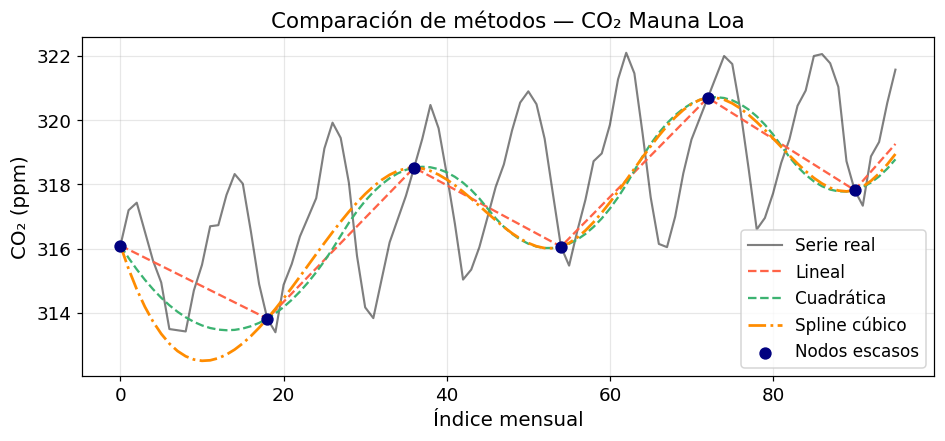

In [127]:
# Spline cúbico con los mismos nodos escasos
cs       = CubicSpline(t_escaso, y_escaso)
y_spline = cs(tiempo)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(tiempo[seg], co2_vals[seg],
        'k-', linewidth=1.4, alpha=0.5, label='Serie real')
ax.plot(tiempo[seg], y_lineal[seg],
        '--', color='tomato', linewidth=1.5, label='Lineal')
ax.plot(tiempo[seg], y_cuad[seg],
        '--', color='mediumseagreen', linewidth=1.5, label='Cuadrática')
ax.plot(tiempo[seg], y_spline[seg],
        '-.',  color='darkorange', linewidth=1.8, label='Spline cúbico')
ax.scatter(t_escaso[t_escaso <= tiempo[seg.stop - 1]],
           y_escaso[t_escaso <= tiempo[seg.stop - 1]],
           s=50, color='navy', zorder=5, label='Nodos dispersos')

ax.set_title('Comparación de métodos — CO₂ Mauna Loa', fontsize=14)
ax.set_xlabel('Índice mensual', fontsize=13)
ax.set_ylabel('CO₂ (ppm)', fontsize=13)
ax.tick_params(labelsize=12)
ax.legend(fontsize=11)

Una cuestión importante de todo método es evaluar qué tan bueno es frente a los datos reales. Para esto, existen técnicas de verificación o puntuación.

In [128]:
# Error cuadrático medio (RMSE) de cada método frente a la serie real
rmse_lineal = np.sqrt(np.mean((y_lineal - co2_vals)**2))
rmse_cuad   = np.sqrt(np.mean((y_cuad   - co2_vals)**2))
rmse_spline = np.sqrt(np.mean((y_spline - co2_vals)**2))

print(f"RMSE lineal      : {rmse_lineal:.4f} ppm")
print(f"RMSE cuadrática  : {rmse_cuad:.4f} ppm")
print(f"RMSE spline cúb. : {rmse_spline:.4f} ppm")

RMSE lineal      : 2.4413 ppm
RMSE cuadrática  : 2.7474 ppm
RMSE spline cúb. : 2.6976 ppm


<div class="alert alert-block alert-info">
<b>Nota sobre extrapolación:</b> <code>interp1d</code> genera un <code>ValueError</code> si se evalúa fuera del rango de los nodos, a menos que se pase <code>fill_value='extrapolate'</code>. <code>CubicSpline</code>, en cambio, extrapola automáticamente usando el polinomio del tramo más cercano al extremo. En ambos casos, extrapolar muy lejos de los datos puede producir resultados físicamente sin sentido.
</div>

---
<a name='ej-1'></a>
### **<font color="DodgerBlue">Ejercicio 1 — Interpolación 1D con datos de temperatura </font>**

<font color="DarkBlue"> En este ejercicio aplicará los métodos de interpolación vistos en clase a una serie temporal de temperatura real y comparará visualmente los resultados.

<font color="DarkBlue"> **Carga de datos** — use exactamente el siguiente bloque:

```python
ds_temp = xr.tutorial.load_dataset('air_temperature')
T_serie = ds_temp['air'].sel(lat=40.0, lon=250.0, method='nearest')
t       = np.arange(len(T_serie))      # índice temporal (pasos de 6 h)
y       = T_serie.values               # temperatura en K
```

<font color="DarkBlue"> **Instrucciones:**

<font color="DarkBlue"> 1. Con la serie completa `(t, y)`, construya una versión **escasa** tomando 1 de cada 20 puntos:
```python
t_esc = t[::20]
y_esc = y[::20]
```

<font color="DarkBlue"> 2. Aplique interpolación **lineal** y **spline cúbico** a los puntos escasos para reconstruir la serie en todos los índices `t`. Grafique las dos reconstrucciones junto con la serie original en una sola figura.

<font color="DarkBlue"> 3. Calcule el RMSE de cada método. La fórmula es:
$$\text{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2}$$
que de hecho vimos en la última celda. ¿Cuál método produce menor error?

<font color="DarkBlue"> 4. Elija una ventana corta (por ejemplo, índices 100 a 200) y haga un zoom de la misma figura para ver con más detalle cómo se comporta cada método entre los nodos escasos. ¿En qué zonas se equivoca más el método lineal?

---

## <font color="darkgreen"> 2. Interpolación espacial y regridding</font>

En esta sección extendemos la interpolación al plano bidimensional. En ciencias de la Tierra esto es fundamental: los modelos climáticos producen campos meteorológicos en mallas regulares, pero muchas veces necesitamos los datos en una resolución diferente o en puntos que no coinciden con la malla original.

Trabajaremos con el campo de **temperatura del aire** del dataset `air_temperature` de xarray, que cubre latitudes de 15°N a 75°N y longitudes de 200°E a 330°E (el Pacífico norte y América del Norte) con resolución de 2.5°. Usaremos **cartopy** para visualizar los campos sobre un mapa con costa y fronteras.

### <font color="deeppink"> 2.1 Interpolación de datos en una malla regular</font>

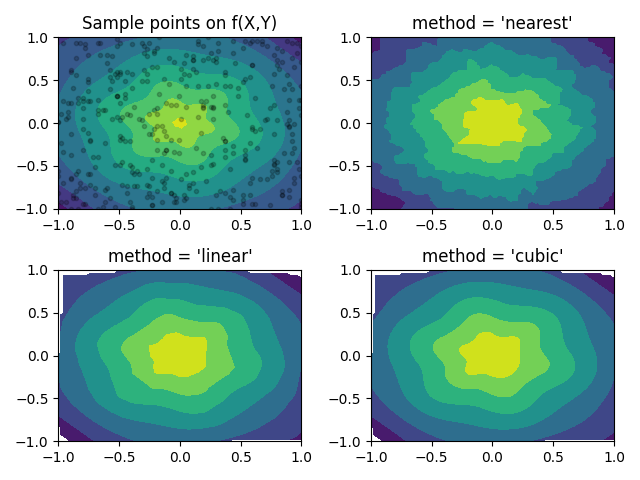

Cuando las observaciones están en puntos **dispersos** (como estaciones meteorológicas distribuidas irregularmente), necesitamos llevarlas a una malla regular para poder graficarlas o combinarlas con otros datasets. La función `scipy.interpolate.griddata` hace exactamente eso: toma coordenadas y valores en puntos arbitrarios y los interpola sobre una malla de destino.

Soporta tres métodos:
- `'nearest'`: asigna a cada punto de la malla el valor de la observación más cercana. Rápido pero produce fronteras abruptas (efecto "teselas").
- `'linear'`: triangulación de Delaunay seguida de interpolación lineal por triángulo. Suave y eficiente.
- `'cubic'`: interpolación cúbica sobre la triangulación. La curva más suave, pero puede producir oscilaciones fuera del dominio convexo de las observaciones.

Simularemos observaciones dispersas muestreando 120 puntos aleatorios del campo de temperatura.

In [129]:
# Cargar el dataset de temperatura del aire
ds = xr.tutorial.load_dataset('air_temperature')
ds

<xarray.Dataset> Size: 31MB
Dimensions:  (lat: 25, time: 2920, lon: 53)
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
Data variables:
    air      (time, lat, lon) float64 31MB 241.2 242.5 243.5 ... 296.2 295.7
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

In [130]:
# Variables de coordenadas
lats = ds.lat.values   # [75, 72.5, ..., 15]  (de norte a sur)
lons = ds.lon.values   # [200, 202.5, ..., 330]
print(f"Latitudes : {lats[0]}°N → {lats[-1]}°N  ({len(lats)} puntos)")
print(f"Longitudes: {lons[0]}°E → {lons[-1]}°E  ({len(lons)} puntos)")


Latitudes : 75.0°N → 15.0°N  (25 puntos)
Longitudes: 200.0°E → 330.0°E  (53 puntos)


In [131]:
# arreglamos el error de las longitudes
ds = ds.assign_coords(lon=((ds.lon.values + 180) % 360 - 180)).sortby('lon')

In [132]:
# Campo original en el primer paso de tiempo
da = ds['air'].isel(time=0)

In [133]:
# Extent para imshow/cartopy: [lon_min, lon_max, lat_min, lat_max]
extent = [float(da.lon.min()), float(da.lon.max()),
          float(da.lat.min()), float(da.lat.max())]
print(extent)

[-160.0, -30.0, 15.0, 75.0]


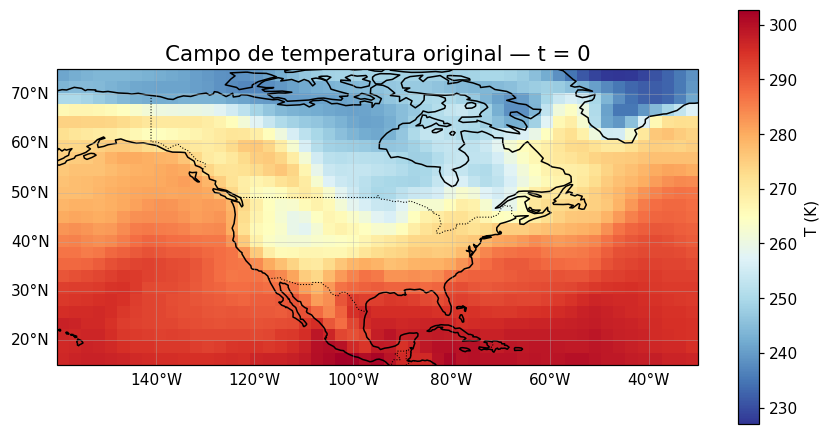

In [134]:
fig = plt.figure(figsize=(8, 5))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# da.values tiene lat de norte a sur → origin='upper'
im = ax.imshow(da,
               origin='upper', extent=extent,
               transform=ccrs.PlateCarree(),
               cmap='RdYlBu_r')

ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.7)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels   = False
gl.right_labels = False

ax.set_title('Campo de temperatura original — t = 0', fontsize=14)
ax.tick_params(labelsize=12)
plt.colorbar(im, ax=ax, label='T (K)', shrink=0.8)
plt.tight_layout()

Ahora vamos a tomar 120 puntos al azar y construiremos primero una malla con estos puntos de nuestros datos. 

In [135]:
# Simular observaciones dispersas: muestreo aleatorio de 120 puntos de la malla
np.random.seed(42)
n_obs   = 120
LAT2D, LON2D = np.meshgrid(lats, lons, indexing='ij')   # forma (25, 53)

idx_rnd = np.random.choice(LAT2D.size, n_obs, replace=False)
obs_lat = LAT2D.ravel()[idx_rnd]
obs_lon = LON2D.ravel()[idx_rnd]
obs_T   = da.values.ravel()[idx_rnd]

print(f"Malla original  : {LAT2D.shape} = {LAT2D.size} puntos")
print(f"Observaciones   : {n_obs} puntos dispersos")

Malla original  : (25, 53) = 1325 puntos
Observaciones   : 120 puntos dispersos


/tmp/ipykernel_23316/3115579684.py:16: UserWarning: Adding colorbar to a different Figure <Figure size 880x550 with 2 Axes> than <Figure size 880x550 with 2 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, label='T (K)', shrink=0.8)


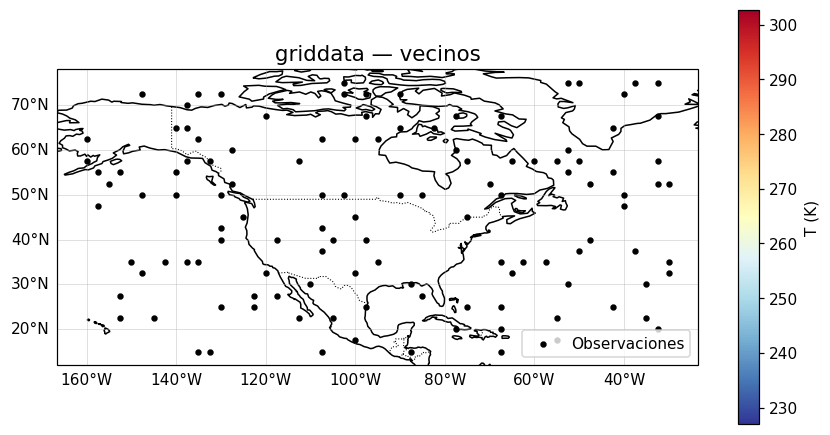

In [136]:
# Visualización comparativa — vecino más cercano
fig = plt.figure(figsize=(8, 5))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.scatter(obs_lon, obs_lat, s=10, c='k',
           transform=ccrs.PlateCarree(), zorder=5, label='Observaciones')
# estética de los graficos
ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.7)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False; gl.right_labels = False

ax.set_title('griddata — vecinos', fontsize=14)
ax.tick_params(labelsize=12)
ax.legend(fontsize=10)
plt.colorbar(im, ax=ax, label='T (K)', shrink=0.8)
plt.tight_layout()

Luego sí usamos la función griddata con 3 diferentes parámetros: `scipy.interpolate.griddata`

In [137]:
# Malla regular de destino (de sur a norte → origin='lower')
lat_fine = np.linspace(lats.min(), lats.max(), 100)
lon_fine = np.linspace(lons.min(), lons.max(), 100)
LAT_fine, LON_fine = np.meshgrid(lat_fine, lon_fine, indexing='ij')

# Interpolación con griddata — los tres métodos
puntos = np.column_stack([obs_lat, obs_lon])

T_nearest = griddata(puntos, obs_T, (LAT_fine, LON_fine), method='nearest')
T_lineal  = griddata(puntos, obs_T, (LAT_fine, LON_fine), method='linear')
T_cubico  = griddata(puntos, obs_T, (LAT_fine, LON_fine), method='cubic')

vmin, vmax = float(da.min()), float(da.max())
print(f"Rango de temperatura: {vmin:.1f} – {vmax:.1f} K")

Rango de temperatura: 227.0 – 302.6 K


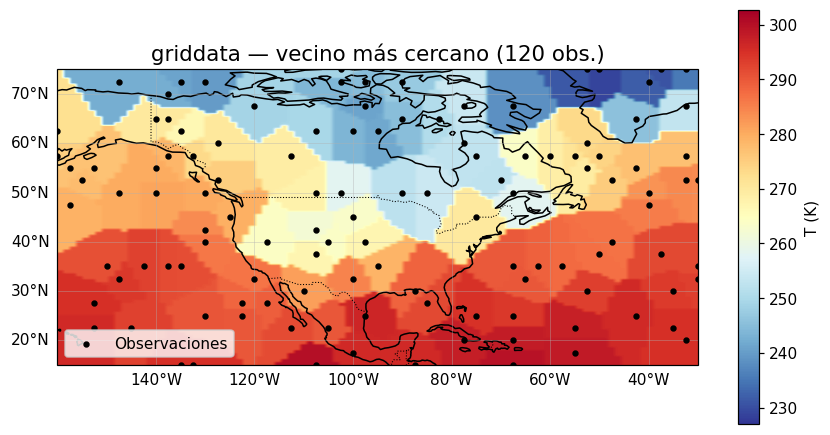

In [138]:
# Visualización comparativa — vecino más cercano
fig = plt.figure(figsize=(8, 5))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

im = ax.imshow(T_nearest,
               origin='lower', extent=extent,
               transform=ccrs.PlateCarree(),
               cmap='RdYlBu_r', vmin=vmin, vmax=vmax)

ax.scatter(obs_lon, obs_lat, s=10, c='k',
           transform=ccrs.PlateCarree(), zorder=5, label='Observaciones')
ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.7)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False; gl.right_labels = False

ax.set_title('griddata — vecino más cercano (120 obs.)', fontsize=14)
ax.tick_params(labelsize=12)
ax.legend(fontsize=10)
plt.colorbar(im, ax=ax, label='T (K)', shrink=0.8)
plt.tight_layout()

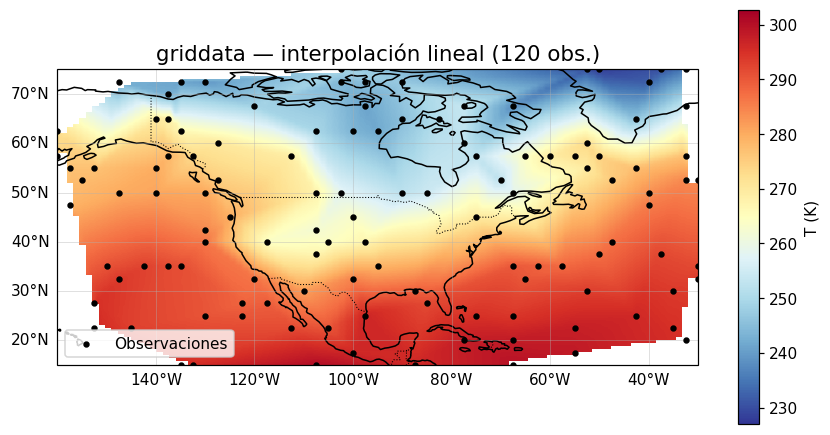

In [139]:
# Visualización comparativa — interpolación lineal
fig = plt.figure(figsize=(8, 5))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

im = ax.imshow(T_lineal,
               origin='lower', extent=extent,
               transform=ccrs.PlateCarree(),
               cmap='RdYlBu_r', vmin=vmin, vmax=vmax)

ax.scatter(obs_lon, obs_lat, s=10, c='k',
           transform=ccrs.PlateCarree(), zorder=5, label='Observaciones')
ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.7)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False; gl.right_labels = False

ax.set_title('griddata — interpolación lineal (120 obs.)', fontsize=14)
ax.tick_params(labelsize=12)
ax.legend(fontsize=10)
plt.colorbar(im, ax=ax, label='T (K)', shrink=0.8)
plt.tight_layout()

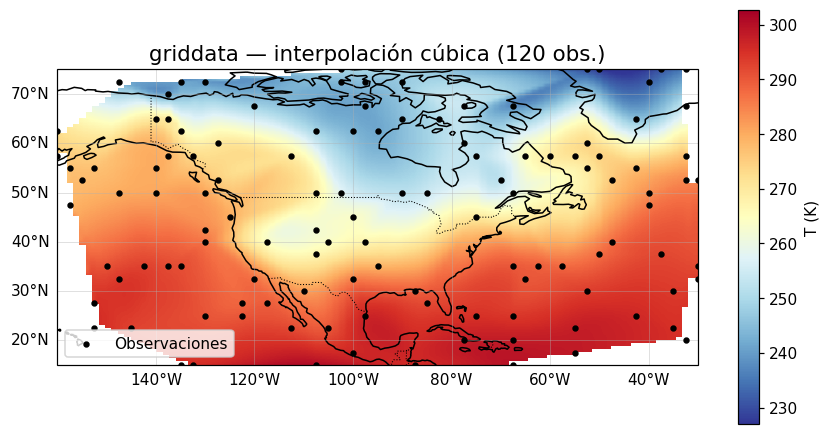

In [140]:
# Visualización comparativa — interpolación cúbica
fig = plt.figure(figsize=(8, 5))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

im = ax.imshow(T_cubico,
               origin='lower', extent=extent,
               transform=ccrs.PlateCarree(),
               cmap='RdYlBu_r', vmin=vmin, vmax=vmax)

ax.scatter(obs_lon, obs_lat, s=10, c='k',
           transform=ccrs.PlateCarree(), zorder=5, label='Observaciones')
ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.7)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False; gl.right_labels = False

ax.set_title('griddata — interpolación cúbica (120 obs.)', fontsize=14)
ax.tick_params(labelsize=12)
ax.legend(fontsize=10)
plt.colorbar(im, ax=ax, label='T (K)', shrink=0.8)
plt.tight_layout()

Comparando los tres mapas se observa claramente la diferencia entre los métodos:

- **Vecino más cercano** produce una especie de "teselas" de Voronoi: cada región tiene un color uniforme correspondiente a la observación más cercana. No hay suavidad entre los bordes.
- **Lineal** produce una transición suave entre observaciones pero con esquinas visibles en la frontera de cada triángulo de la triangulación.
- **Cúbico** produce la superficie más suave de las tres, aunque puede tener valores ligeramente fuera del rango original en zonas con poca cobertura de observaciones (aparece como `NaN` fuera del casco convexo).

### <font color="deeppink"> 2.2 Interpolación espacial con `xarray.interp`</font>

Cuando los datos ya están organizados en un `xarray.DataArray` sobre una malla regular, la forma más conveniente de interpolarlos a nuevas coordenadas es el método `.interp()`. Éste usa SciPy internamente y trabaja directamente con los nombres de coordenadas del dataset, sin necesidad de construir mallas a mano.

La sintaxis básica es:
```python
da.interp(lat=nuevas_lats, lon=nuevos_lons)
```

El argumento `method` acepta `'linear'` (por defecto), `'nearest'`, `'quadratic'` y `'cubic'`.

In [141]:
# Versión degradada: 1 de cada 3 puntos en lat y lon
da_gruesa = da.isel(lat=slice(None, None, 3),
                    lon=slice(None, None, 3))

print(f"Malla original  : {da.shape}")
print(f"Malla degradada : {da_gruesa.shape}")

Malla original  : (25, 53)
Malla degradada : (9, 18)


In [142]:
# Interpolación a la malla original usando xarray.interp
da_interp_lineal  = da_gruesa.interp(lat=da.lat, lon=da.lon, method='linear')
da_interp_cubico  = da_gruesa.interp(lat=da.lat, lon=da.lon, method='cubic')

print("Forma tras interpolación lineal :", da_interp_lineal.shape)
print("Forma tras interpolación cúbica :", da_interp_cubico.shape)

Forma tras interpolación lineal : (25, 53)
Forma tras interpolación cúbica : (25, 53)


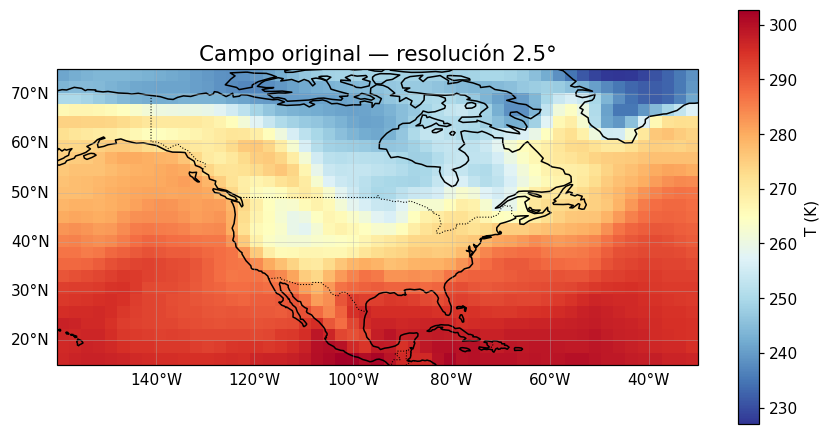

In [143]:
# Mapa 1: campo original (alta resolución)
fig = plt.figure(figsize=(8, 5))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

im = ax.imshow(da.values,
               origin='upper', extent=extent,
               transform=ccrs.PlateCarree(),
               cmap='RdYlBu_r')

ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.7)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False; gl.right_labels = False

ax.set_title('Campo original — resolución 2.5°', fontsize=14)
ax.tick_params(labelsize=12)
plt.colorbar(im, ax=ax, label='T (K)', shrink=0.8)
plt.tight_layout()

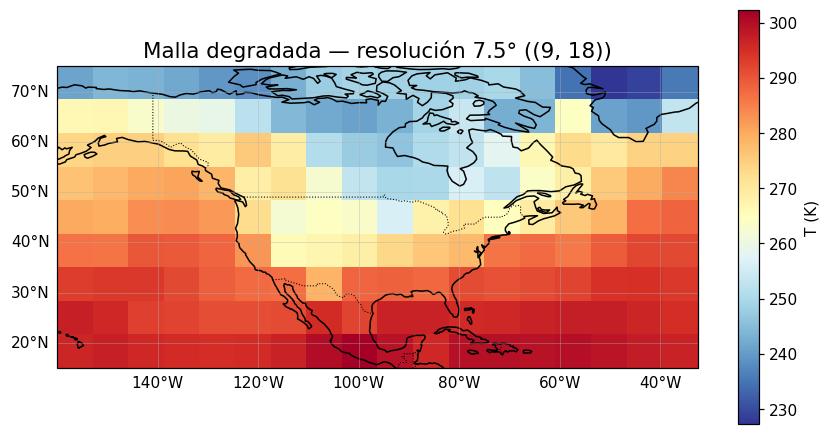

In [144]:
# Mapa 2: campo en malla degradada (3× menos resolución)
fig = plt.figure(figsize=(8, 5))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

extent_gruesa = [float(da_gruesa.lon.min()), float(da_gruesa.lon.max()),
                 float(da_gruesa.lat.min()), float(da_gruesa.lat.max())]

im = ax.imshow(da_gruesa.values,
               origin='upper', extent=extent_gruesa,
               transform=ccrs.PlateCarree(),
               cmap='RdYlBu_r',
               interpolation='nearest')   # sin suavizado de imshow

ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.7)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False; gl.right_labels = False

ax.set_title(f'Malla degradada — resolución 7.5° ({da_gruesa.shape})', fontsize=14)
ax.tick_params(labelsize=12)
plt.colorbar(im, ax=ax, label='T (K)', shrink=0.8)
plt.tight_layout()

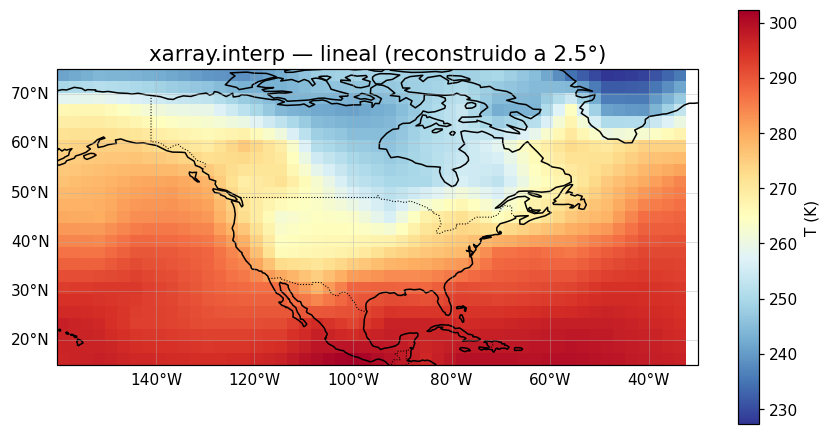

In [145]:
# Mapa 3: campo reconstruido con xarray.interp lineal
fig = plt.figure(figsize=(8, 5))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

im = ax.imshow(da_interp_lineal.values,
               origin='upper', extent=extent,
               transform=ccrs.PlateCarree(),
               cmap='RdYlBu_r')

ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.7)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False; gl.right_labels = False

ax.set_title('xarray.interp — lineal (reconstruido a 2.5°)', fontsize=14)
ax.tick_params(labelsize=12)
plt.colorbar(im, ax=ax, label='T (K)', shrink=0.8)
plt.tight_layout()

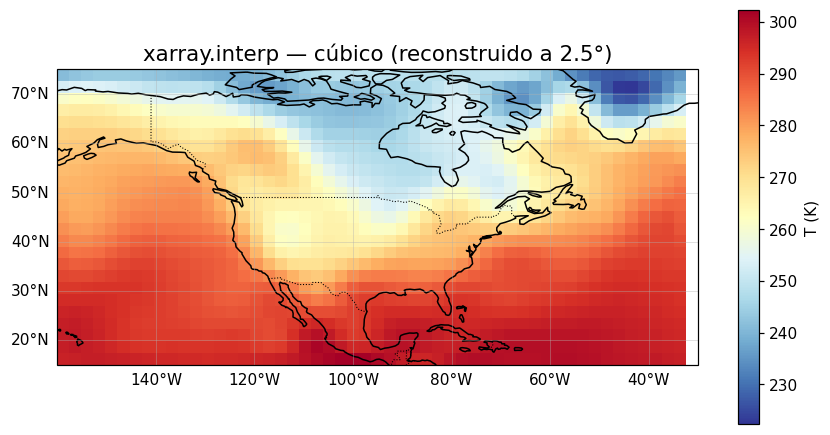

In [146]:
# Mapa 4: campo reconstruido con xarray.interp cúbico
fig = plt.figure(figsize=(8, 5))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

im = ax.imshow(da_interp_cubico.values,
               origin='upper', extent=extent,
               transform=ccrs.PlateCarree(),
               cmap='RdYlBu_r')

ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.7)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False; gl.right_labels = False

ax.set_title('xarray.interp — cúbico (reconstruido a 2.5°)', fontsize=14)
ax.tick_params(labelsize=12)
plt.colorbar(im, ax=ax, label='T (K)', shrink=0.8)
plt.tight_layout()

In [147]:
# RMSE de cada método frente al campo original
rmse_lineal = float(np.sqrt(((da_interp_lineal - da)**2).mean()))
rmse_cubico = float(np.sqrt(((da_interp_cubico - da)**2).mean()))

print(f"RMSE lineal : {rmse_lineal:.4f} K")
print(f"RMSE cúbico : {rmse_cubico:.4f} K")

RMSE lineal : 2.5221 K
RMSE cúbico : 2.6049 K


<div class="alert alert-block alert-info">
<b>Interpolación temporal con xarray.interp:</b> El método <code>.interp()</code> también funciona sobre la dimensión temporal. Por ejemplo, para pasar de pasos de 6 horas a pasos de 1 hora basta con:
<pre>
t_horario = pd.date_range(ds.time[0].values, ds.time[-1].values, freq='1h')
da_horario = ds['air'].sel(lat=40.0, lon=250.0, method='nearest').interp(time=t_horario, method='cubic')
</pre>
Esto es muy útil para sincronizar series de distintos productos con diferente resolución temporal.
</div>

### <font color="deeppink"> 2.3 Regridding entre mallas con `xESMF`</font>

`xarray.interp` es ideal para mallas rectangulares regulares. Sin embargo, en meteorología y oceanografía es común trabajar con mallas más complejas: **mallas curvilíneas**, **mallas no estructuradas** o mallas distintas entre un modelo de circulación general y un producto de reanálisis.

Para estos casos existe **`xESMF`** (*Earth System Modeling Framework Regridder*), construido sobre el motor ESMF desarrollado por NCAR. Sus ventajas principales son:

- Soporta regridding entre **cualquier par de mallas**, incluyendo no estructuradas y curvilíneas.
- Implementa tres métodos: **bilineal**, **conservativo** (que preserva el promedio areal, fundamental para flujos de masa y energía) y **vecino más cercano**.
- Trabaja directamente con objetos `xarray.Dataset`.

<div class="alert alert-block alert-warning">
<b>Instalación:</b> <code>xESMF</code> requiere el paquete <code>ESMF</code>, cuya instalación es compleja fuera de <code>conda</code>. La forma recomendada es:
<pre>conda install -c conda-forge xesmf</pre>
No ejecutamos código de <code>xESMF</code> en este notebook para evitar problemas de entorno, pero su documentación oficial en <a href="https://xesmf.readthedocs.io">xesmf.readthedocs.io</a> incluye tutoriales con datos climáticos reales.
</div>

```python
import xesmf as xe

# Malla de destino definida como Dataset con coordenadas lat/lon
ds_out = xr.Dataset({
    'lat': (['lat'], np.arange(15, 75.1, 1.0)),
    'lon': (['lon'], np.arange(200, 330.1, 1.0)),
})

# Crear el objeto regridder (se puede reutilizar para múltiples variables)
regridder = xe.Regridder(ds, ds_out, method='bilinear')

# Aplicar el remapeo
ds_remapeado = regridder(ds['air'])
```

---
<a name='ej-2'></a>
### **<font color="DodgerBlue">Ejercicio 2 — Interpolación espacial con malla escasa y cartopy </font>**

<font color="DarkBlue"> En este ejercicio simulará lo que ocurre cuando una red de estaciones meteorológicas tiene distribución irregular y se quiere reconstruir el campo completo de temperatura.

<font color="DarkBlue"> **Instrucciones:**

<font color="DarkBlue"> 1. Cargue el dataset `air_temperature` y seleccione el campo en el **último** paso de tiempo (`isel(time=-1)`).

<font color="DarkBlue"> 2. Simule una red de **60 estaciones** dispersas muestreando aleatoriamente 60 puntos de la malla (use `np.random.seed(7)` para reproducibilidad). Grafíquelas sobre un mapa de cartopy usando `ax.scatter(obs_lon, obs_lat, ...)`.

<font color="DarkBlue"> 3. Con `scipy.interpolate.griddata`, reconstruya el campo en una malla fina (al menos 80×80) usando los métodos `'linear'` y `'cubic'`. Grafique cada resultado en un mapa con cartopy usando `ax.imshow(...)`.

<font color="DarkBlue"> 4. En una figura adicional, grafique la **diferencia** entre la reconstrucción cúbica y el campo original del dataset, usando un mapa de divergencia (`cmap='RdBu_r'`) centrado en cero. ¿En qué regiones es mayor el error? ¿Coincide con las zonas de menor densidad de estaciones?

<font color="DarkBlue"> 5. Repita el paso 3 pero ahora con **200 estaciones** (mismo `random.seed`). ¿Cómo cambia la calidad de la reconstrucción?

---

In [148]:
# Espacio para el Ejercicio 2


## <font color="darkgreen"> 3. Integración numérica</font>

La **integración numérica** (o cuadratura numérica) permite calcular la integral definida de una función cuando sólo conocemos sus valores en un conjunto discreto de puntos, sin disponer de una expresión analítica. Esto es exactamente la situación habitual en ciencias de la Tierra: los instrumentos registran en instantes discretos de tiempo o en posiciones discretas del espacio.

Comenzaremos con una función de prueba cuya integral analítica conocemos, lo que nos permitirá cuantificar el error de cada método. Después aplicaremos los mismos métodos a la serie real de CO₂.

### <font color="deeppink"> 3.1 La integral como área bajo la curva</font>

La integral definida

\begin{align}
I = \int_a^b f(x)\, dx
\end{align}

representa el **área con signo** entre la curva $f(x)$ y el eje $x$ en el intervalo $[a, b]$. Cuando $f(x) > 0$ la contribución es positiva; cuando $f(x) < 0$, negativa.

En la práctica, si tenemos $n+1$ puntos $x_0 < x_1 < \cdots < x_n$ con sus valores $y_i = f(x_i)$, necesitamos una regla para aproximar esa área usando únicamente esos valores discretos. Los métodos de cuadratura difieren en **cómo aproximan la función entre puntos consecutivos**.

Usaremos como función de prueba $f(x) = \sin(x)$ en $[0, \pi]$, cuya integral analítica es exactamente 2.

In [149]:
# Función de prueba y valor exacto
x_fino  = np.linspace(0, np.pi, 500)
y_fino  = np.sin(x_fino)
I_exact = 2.0   # ∫₀^π sin(x) dx = 2

# Puntos discretos con n = 9 (8 subintervalos)
n_pts = 9
x_pts = np.linspace(0, np.pi, n_pts)
y_pts = np.sin(x_pts)

print(f"Valor exacto de la integral: {I_exact}")

Valor exacto de la integral: 2.0


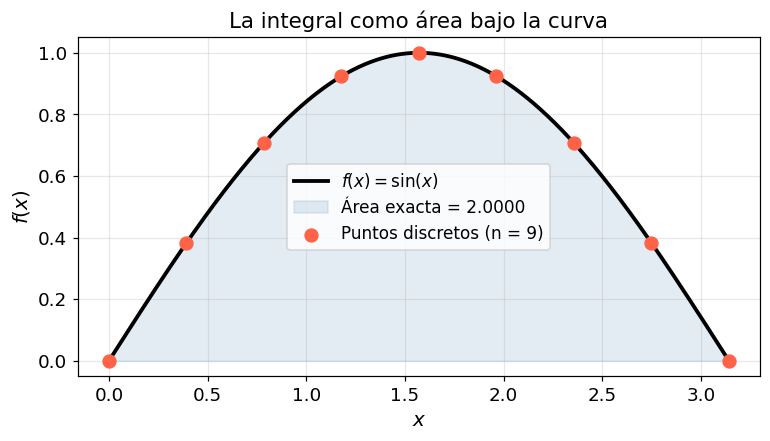

In [150]:
# Visualizar el área bajo la curva
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x_fino, y_fino, 'k-', linewidth=2.5, label='$f(x) = \sin(x)$')
ax.fill_between(x_fino, y_fino, alpha=0.15, color='steelblue',
                label=f'Área exacta = {I_exact:.4f}')
ax.scatter(x_pts, y_pts, s=70, color='tomato', zorder=5,
           label=f'Puntos discretos (n = {n_pts})')

ax.set_title('La integral como área bajo la curva', fontsize=14)
ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('$f(x)$', fontsize=13)
ax.tick_params(labelsize=12)
ax.legend(fontsize=11)

### <font color="deeppink"> 3.2 Regla del rectángulo y regla del trapecio</font>

**Regla del rectángulo (punto medio):**
Aproxima la función en cada subintervalo $[x_i, x_{i+1}]$ por su valor en el punto medio $m_i = (x_i + x_{i+1})/2$:

\begin{align}
I \approx \sum_{i=0}^{n-1} (x_{i+1}-x_i)\, f(m_i)
\end{align}

**Regla del trapecio:**
Aproxima la función con una recta entre los dos extremos de cada subintervalo, formando un trapecio:

\begin{align}
I \approx \frac{h}{2}\left[f(x_0) + 2f(x_1) + 2f(x_2) + \cdots + 2f(x_{n-1}) + f(x_n)\right]
\end{align}

SciPy implementa la regla del trapecio en `scipy.integrate.trapezoid(y, x)`.

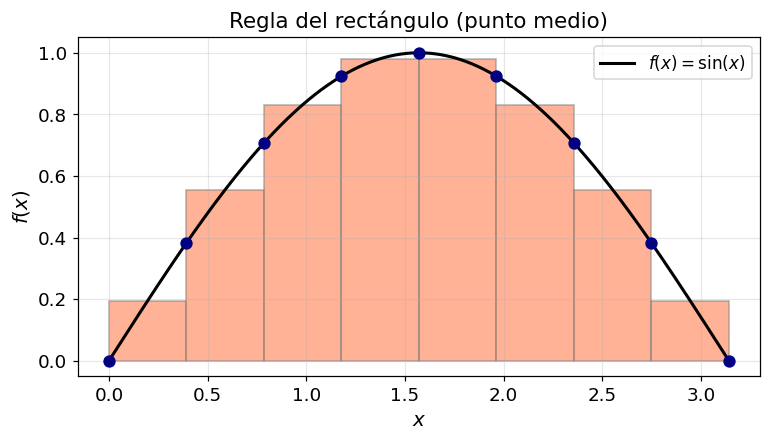

In [151]:
# Visualizar la regla del rectángulo (punto medio)
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x_fino, y_fino, 'k-', linewidth=2, zorder=5, label='$f(x) = \sin(x)$')

for i in range(n_pts - 1):
    xm = (x_pts[i] + x_pts[i + 1]) / 2
    ym = np.sin(xm)
    rect = plt.Polygon([[x_pts[i], 0], [x_pts[i], ym],
                         [x_pts[i + 1], ym], [x_pts[i + 1], 0]],
                        closed=True, facecolor='coral', edgecolor='gray',
                        alpha=0.6)
    ax.add_patch(rect)

ax.scatter(x_pts, y_pts, s=50, color='navy', zorder=6)
ax.set_title('Regla del rectángulo (punto medio)', fontsize=14)
ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('$f(x)$', fontsize=13)
ax.tick_params(labelsize=12)
ax.legend(fontsize=11)

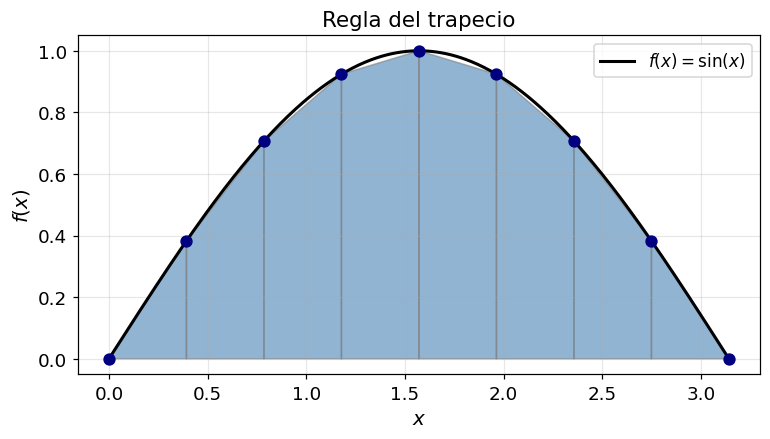

In [152]:
# Visualizar la regla del trapecio
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x_fino, y_fino, 'k-', linewidth=2, zorder=5, label='$f(x) = \sin(x)$')

for i in range(n_pts - 1):
    trap = plt.Polygon([[x_pts[i], 0], [x_pts[i], y_pts[i]],
                         [x_pts[i + 1], y_pts[i + 1]], [x_pts[i + 1], 0]],
                        closed=True, facecolor='steelblue', edgecolor='gray',
                        alpha=0.6)
    ax.add_patch(trap)

ax.scatter(x_pts, y_pts, s=50, color='navy', zorder=6)
ax.set_title('Regla del trapecio', fontsize=14)
ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('$f(x)$', fontsize=13)
ax.tick_params(labelsize=12)
ax.legend(fontsize=11)

In [153]:
# Cálculo numérico y comparación con el valor exacto
x_medios = (x_pts[:-1] + x_pts[1:]) / 2
I_rect   = float(np.sum(np.sin(x_medios) * np.diff(x_pts)))
I_trap   = float(trapezoid(y_pts, x_pts))

print(f"Valor exacto     : {I_exact:.8f}")
print(f"Rectángulo       : {I_rect:.8f}   (error = {abs(I_rect - I_exact):.2e})")
print(f"Trapecio         : {I_trap:.8f}   (error = {abs(I_trap - I_exact):.2e})")

Valor exacto     : 2.00000000
Rectángulo       : 2.01290909   (error = 1.29e-02)
Trapecio         : 1.97423160   (error = 2.58e-02)


### <font color="deeppink"> 3.3 Regla de Simpson y comparación entre métodos</font>

La **regla de Simpson** aproxima la función en cada par de subintervalos con una **parábola** en lugar de una recta. Esto produce un error considerablemente menor con el mismo número de puntos:

\begin{align}
I \approx \frac{h}{3}\left[f(x_0) + 4f(x_1) + 2f(x_2) + 4f(x_3) + \cdots + 4f(x_{n-1}) + f(x_n)\right]
\end{align}

La tabla siguiente resume las tasas de convergencia teóricas de cada método:

| Método | Aproximación local | Error global |
|--------|-------------------|-------------|
| Rectángulo | Constante | $O(h^2)$ |
| Trapecio | Lineal | $O(h^2)$ |
| Simpson | Cuadrática (parábola) | $O(h^4)$ |

El error de Simpson decrece **mucho más rápido** al reducir el tamaño de paso $h$. SciPy lo implementa en `scipy.integrate.simpson(y, x=x)`.

In [154]:
# Cálculo con Simpson y comparación directa
I_simp = float(simpson(y_pts, x=x_pts))

print(f"Valor exacto     : {I_exact:.8f}")
print(f"Rectángulo       : {I_rect:.8f}   (error = {abs(I_rect - I_exact):.2e})")
print(f"Trapecio         : {I_trap:.8f}   (error = {abs(I_trap - I_exact):.2e})")
print(f"Simpson          : {I_simp:.8f}   (error = {abs(I_simp - I_exact):.2e})")

Valor exacto     : 2.00000000
Rectángulo       : 2.01290909   (error = 1.29e-02)
Trapecio         : 1.97423160   (error = 2.58e-02)
Simpson          : 2.00026917   (error = 2.69e-04)


In [155]:
# Convergencia sistemática: cómo cae el error al aumentar n
n_lista   = [5, 9, 17, 33, 65, 129]
err_rect  = []
err_trap  = []
err_simp  = []

for n in n_lista:
    xv = np.linspace(0, np.pi, n)
    yv = np.sin(xv)

    xm  = (xv[:-1] + xv[1:]) / 2
    I_r = float(np.sum(np.sin(xm) * np.diff(xv)))
    I_t = float(trapezoid(yv, xv))
    I_s = float(simpson(yv, x=xv))

    err_rect.append(abs(I_r - I_exact))
    err_trap.append(abs(I_t - I_exact))
    err_simp.append(abs(I_s - I_exact))

# Tabla de errores
print(f"{'n':>6}  {'Rectángulo':>14}  {'Trapecio':>14}  {'Simpson':>14}")
print("-" * 55)
for n, er, et, es in zip(n_lista, err_rect, err_trap, err_simp):
    print(f"{n:>6}  {er:>14.2e}  {et:>14.2e}  {es:>14.2e}")

     n      Rectángulo        Trapecio         Simpson
-------------------------------------------------------
     5        5.23e-02        1.04e-01        4.56e-03
     9        1.29e-02        2.58e-02        2.69e-04
    17        3.22e-03        6.43e-03        1.66e-05
    33        8.03e-04        1.61e-03        1.03e-06
    65        2.01e-04        4.02e-04        6.45e-08
   129        5.02e-05        1.00e-04        4.03e-09


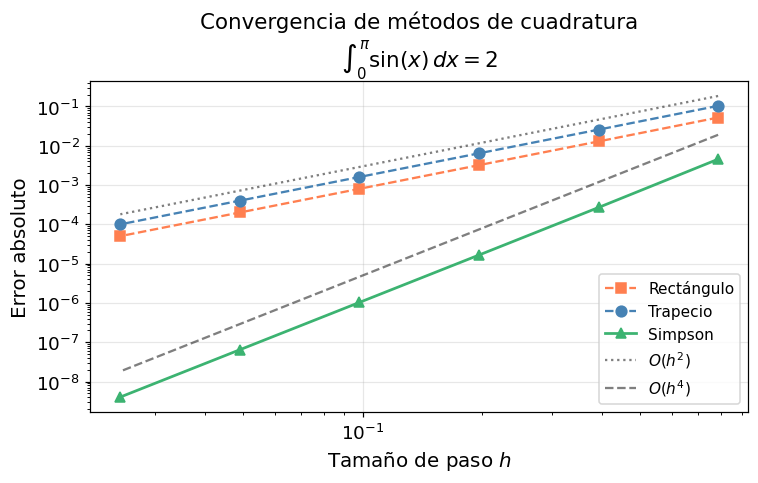

In [156]:
# Gráfica de convergencia en escala log-log
h_vals = np.pi / (np.array(n_lista) - 1)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.loglog(h_vals, err_rect,  's--', color='coral',         linewidth=1.5, ms=7,
          label='Rectángulo')
ax.loglog(h_vals, err_trap,  'o--', color='steelblue',     linewidth=1.5, ms=7,
          label='Trapecio')
ax.loglog(h_vals, err_simp,  '^-',  color='mediumseagreen',linewidth=1.8, ms=7,
          label='Simpson')

# Tasas de referencia
ax.loglog(h_vals, 0.3 * h_vals**2, 'k:',  alpha=0.5, label='$O(h^2)$')
ax.loglog(h_vals, 0.05 * h_vals**4,'k--', alpha=0.5, label='$O(h^4)$')

ax.set_title('Convergencia de métodos de cuadratura\n'
             r'$\int_0^{\pi} \sin(x)\, dx = 2$', fontsize=14)
ax.set_xlabel('Tamaño de paso $h$', fontsize=13)
ax.set_ylabel('Error absoluto', fontsize=13)
ax.tick_params(labelsize=12)
ax.legend(fontsize=10)
plt.tight_layout()

La pendiente de cada curva en la gráfica log-log confirma las tasas teóricas: rectángulo y trapecio caen con pendiente $-2$ (error $O(h^2)$), mientras Simpson cae con pendiente $-4$ (error $O(h^4)$). Esto significa que si dividimos el paso a la mitad, el error de Simpson se divide por **16**, mientras que el de trapecio sólo por **4**.

In [157]:
# Aplicación real: exceso acumulado de CO₂ sobre el nivel de 1958
co2_serie  = df_co2_filled['co2'].values
tiempo_mes = np.arange(len(co2_serie), dtype=float)   # en meses desde ene-1958
co2_base   = co2_serie[0]                              # referencia: nivel inicial
co2_exceso = co2_serie - co2_base

I_trap_co2 = float(trapezoid(co2_exceso, tiempo_mes))
I_simp_co2 = float(simpson(co2_exceso, x=tiempo_mes))

print(f"CO₂ base (ene-1958)          : {co2_base:.2f} ppm")
print(f"Integral (trapecio)          : {I_trap_co2:.2f} ppm·mes")
print(f"Integral (Simpson)           : {I_simp_co2:.2f} ppm·mes")
print(f"Diferencia entre métodos     : {abs(I_trap_co2 - I_simp_co2):.4f} ppm·mes")

CO₂ base (ene-1958)          : 316.10 ppm
Integral (trapecio)          : 12343.64 ppm·mes
Integral (Simpson)           : 12344.74 ppm·mes
Diferencia entre métodos     : 1.0969 ppm·mes


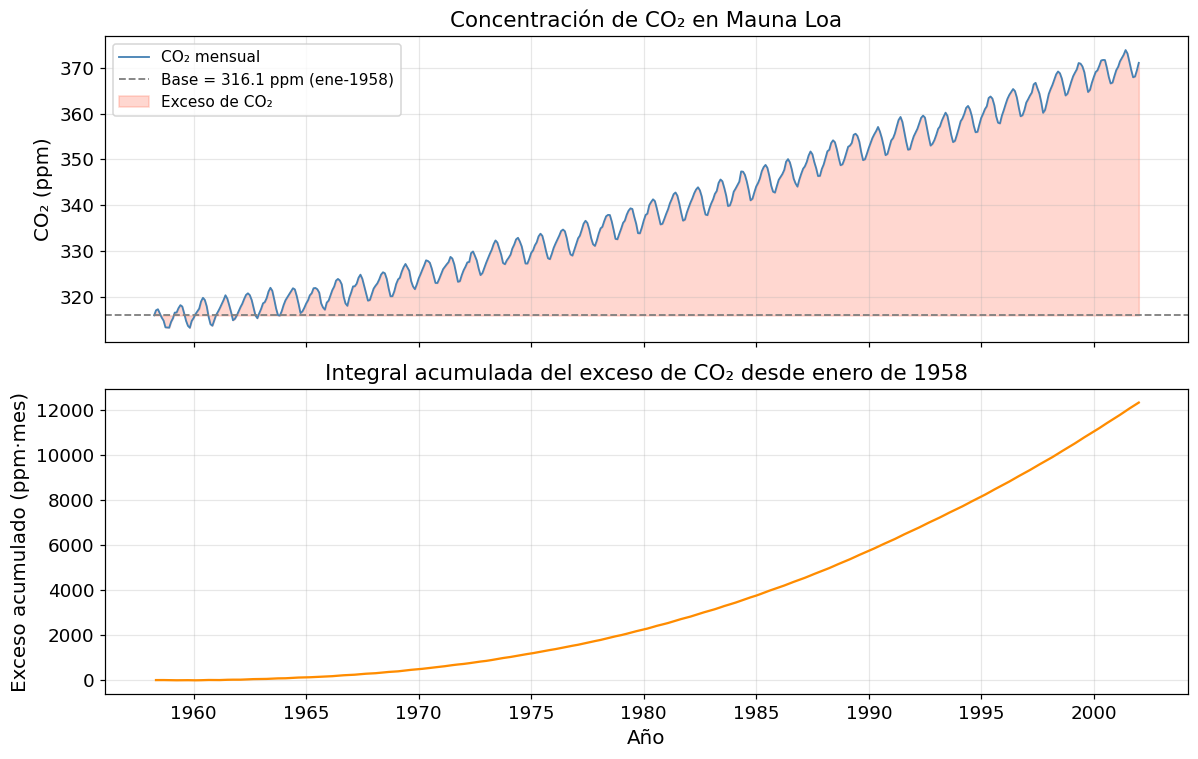

In [158]:
# Integral acumulada: cuánto exceso de CO₂ se ha acumulado desde 1958
integral_acum = np.array([
    trapezoid(co2_exceso[:i + 1], tiempo_mes[:i + 1])
    for i in range(1, len(tiempo_mes))
])

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Panel superior: serie de CO₂ con exceso sombreado
axes[0].plot(df_co2_filled.index, co2_serie,
             color='steelblue', linewidth=1.2, label='CO₂ mensual')
axes[0].axhline(co2_base, linestyle='--', color='gray', linewidth=1.2,
                label=f'Base = {co2_base:.1f} ppm (ene-1958)')
axes[0].fill_between(df_co2_filled.index, co2_base, co2_serie,
                     alpha=0.25, color='tomato', label='Exceso de CO₂')
axes[0].set_ylabel('CO₂ (ppm)', fontsize=13)
axes[0].set_title('Concentración de CO₂ en Mauna Loa', fontsize=14)
axes[0].tick_params(labelsize=12)
axes[0].legend(fontsize=10)

# Panel inferior: exceso acumulado
axes[1].plot(df_co2_filled.index[1:], integral_acum,
             color='darkorange', linewidth=1.5)
axes[1].set_xlabel('Año', fontsize=13)
axes[1].set_ylabel('Exceso acumulado (ppm·mes)', fontsize=13)
axes[1].set_title('Integral acumulada del exceso de CO₂ desde enero de 1958', fontsize=14)
axes[1].tick_params(labelsize=12)

plt.tight_layout()

---
<a name='ej-3'></a>
### **<font color="DodgerBlue">Ejercicio 3 — Integración numérica de una serie de temperatura </font>**

<font color="DarkBlue"> En este ejercicio aplicará los tres métodos de cuadratura a una serie real de temperatura y analizará cómo varía la precisión en función del número de puntos.

<font color="DarkBlue"> **Carga de datos** — use exactamente el siguiente bloque:
```python
ds_temp  = xr.tutorial.load_dataset('air_temperature')
T_serie  = ds_temp['air'].sel(lat=52.5, lon=260.0, method='nearest')
t_horas  = (T_serie.time.values - T_serie.time.values[0]) / np.timedelta64(1, 'h')
y_temp   = T_serie.values    # temperatura en K
```

<font color="DarkBlue"> **Instrucciones:**

<font color="DarkBlue"> 1. La **temperatura media** puede calcularse como integral dividida entre el intervalo total:
$$\bar{T} = \frac{1}{t_n - t_0} \int_{t_0}^{t_n} T(t)\, dt$$
Calcule $\bar{T}$ con los tres métodos (rectángulo, trapecio y Simpson) y compárela con el promedio aritmético `np.mean(y_temp)`. ¿Coinciden?

<font color="DarkBlue"> 2. Para evaluar la convergencia, remuestree la serie a subconjuntos de $n = 5, 10, 20, 50, 100$ y todos los puntos usando índices igualmente espaciados. Calcule la integral con trapecio y Simpson en cada caso y grafique el error relativo respecto al resultado con todos los puntos en escala log-log.

<font color="DarkBlue"> 3. Haga una figura con dos paneles: en el superior, la serie de temperatura con la media marcada como línea horizontal; en el inferior, coloree el área bajo la curva de **rojo** donde la temperatura está por encima de la media y de **azul** donde está por debajo. *(Pista: use `ax.fill_between` con la condición `where=y_temp >= T_media`)*.

---